In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
from google.colab import drive

drive.mount('/content/drive')

print("Google Drive mounted successfully!")

Mounted at /content/drive
Google Drive mounted successfully!


In [3]:
file_path = "/content/drive/MyDrive/Iris.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (150, 6)


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
print("Dataset Information")
print("=" * 50)

df.info()

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [5]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [6]:
print("Columns in the dataset:")
print(df.columns.tolist())

Columns in the dataset:
['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']


In [7]:
print("Missing Values")
print("=" * 50)

print(df.isnull().sum())

Missing Values
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


In [8]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [9]:
# Remove the ID column because it is only an identifier
df = df.drop(columns=["Id"])

print("ID column removed successfully!")
print("New shape:", df.shape)

df.head()

ID column removed successfully!
New shape: (150, 5)


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [10]:
print("Target Classes:")
print(df["Species"].value_counts())

Target Classes:
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


In [11]:
feature_columns = [
    "SepalLengthCm",
    "SepalWidthCm",
    "PetalLengthCm",
    "PetalWidthCm"
]

target_column = "Species"

X = df[feature_columns]
y = df[target_column]

print("Features:")
print(feature_columns)

print("\nTarget:")
print(target_column)

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

Features:
['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

Target:
Species

Feature shape: (150, 4)
Target shape: (150,)


In [12]:
df.groupby("Species")[feature_columns].mean().round(2)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
Species,,,,
Iris-setosa,5.01,3.42,1.46,0.24
Iris-versicolor,5.94,2.77,4.26,1.33
Iris-virginica,6.59,2.97,5.55,2.03


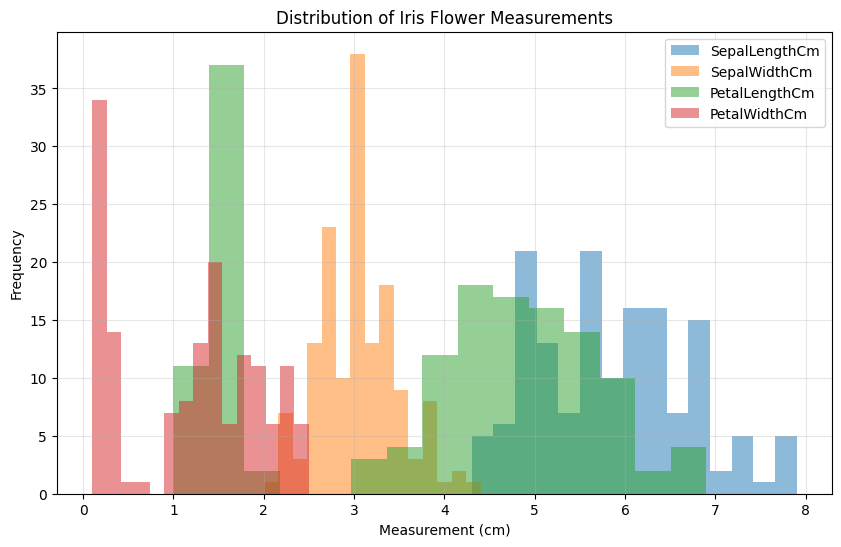

In [13]:
plt.figure(figsize=(10, 6))

for feature in feature_columns:
    plt.hist(df[feature], bins=15, alpha=0.5, label=feature)

plt.title("Distribution of Iris Flower Measurements")
plt.xlabel("Measurement (cm)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

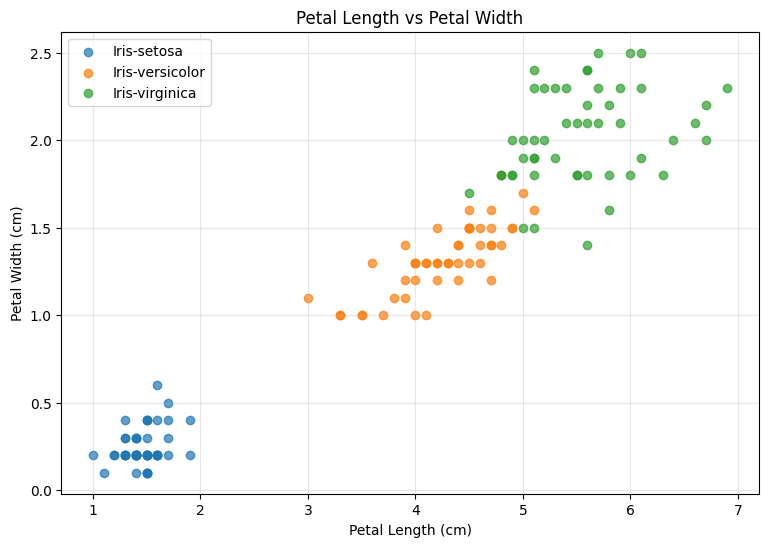

In [14]:
plt.figure(figsize=(9, 6))

for species in df["Species"].unique():
    subset = df[df["Species"] == species]
    plt.scatter(
        subset["PetalLengthCm"],
        subset["PetalWidthCm"],
        label=species,
        alpha=0.7
    )

plt.title("Petal Length vs Petal Width")
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

Feature Correlation Matrix:


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
SepalLengthCm,1.00,-0.11,0.87,0.82
SepalWidthCm,-0.11,1.00,-0.42,-0.36
PetalLengthCm,0.87,-0.42,1.00,0.96
PetalWidthCm,0.82,-0.36,0.96,1.00


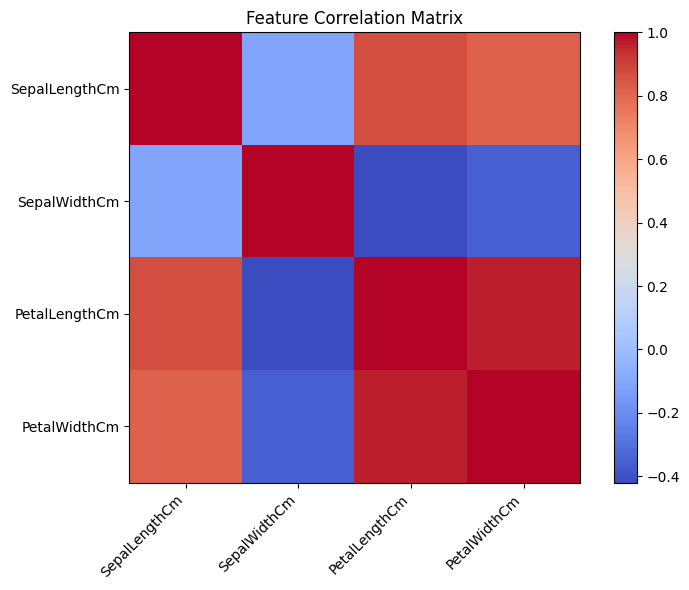

In [15]:
correlation = X.corr()

print("Feature Correlation Matrix:")
display(correlation.round(2))

plt.figure(figsize=(8, 6))
plt.imshow(correlation, cmap="coolwarm", interpolation="nearest")
plt.colorbar()

plt.xticks(range(len(feature_columns)), feature_columns, rotation=45, ha="right")
plt.yticks(range(len(feature_columns)), feature_columns)

plt.title("Feature Correlation Matrix")

plt.tight_layout()
plt.show()

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Data split completed successfully!")
print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Data split completed successfully!
Training samples: 120
Testing samples : 30

Training class distribution:
Species
Iris-setosa        40
Iris-virginica     40
Iris-versicolor    40
Name: count, dtype: int64

Testing class distribution:
Species
Iris-setosa        10
Iris-virginica     10
Iris-versicolor    10
Name: count, dtype: int64


In [17]:
preprocessor = StandardScaler()

print("Preprocessing setup completed!")
print("Method: StandardScaler")

Preprocessing setup completed!
Method: StandardScaler


In [18]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(max_iter=1000, random_state=42))
    ]),

    "K-Nearest Neighbors": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", KNeighborsClassifier(n_neighbors=5))
    ]),

    "Support Vector Machine": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", SVC(kernel="rbf", probability=True, random_state=42))
    ]),

    "Random Forest": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        ))
    ])
}

print("All models defined successfully!")
print("\nModels to be evaluated:")
for model_name in models:
    print("-", model_name)

All models defined successfully!

Models to be evaluated:
- Logistic Regression
- K-Nearest Neighbors
- Support Vector Machine
- Random Forest


In [19]:
results = []

for name, model in models.items():

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(
        y_test, y_pred, average="weighted", zero_division=0
    )
    recall = recall_score(
        y_test, y_pred, average="weighted", zero_division=0
    )
    f1 = f1_score(
        y_test, y_pred, average="weighted", zero_division=0
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

print("MODEL PERFORMANCE COMPARISON")
print("=" * 75)

display(
    results_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1 Score": "{:.4f}"
    })
)

MODEL PERFORMANCE COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score
0,Support Vector Machine,0.9667,0.9697,0.9667,0.9666
1,Logistic Regression,0.9333,0.9333,0.9333,0.9333
2,K-Nearest Neighbors,0.9333,0.9444,0.9333,0.9327
3,Random Forest,0.9000,0.9024,0.9000,0.8997


In [20]:
percentage_results = results_df.copy()

for column in ["Accuracy", "Precision", "Recall", "F1 Score"]:
    percentage_results[column] = (
        percentage_results[column] * 100
    ).round(2)

print("MODEL PERFORMANCE (%)")
print("=" * 75)

display(percentage_results)

MODEL PERFORMANCE (%)


,Model,Accuracy,Precision,Recall,F1 Score
0,Support Vector Machine,96.67,96.97,96.67,96.66
1,Logistic Regression,93.33,93.33,93.33,93.33
2,K-Nearest Neighbors,93.33,94.44,93.33,93.27
3,Random Forest,90.00,90.24,90.00,89.97


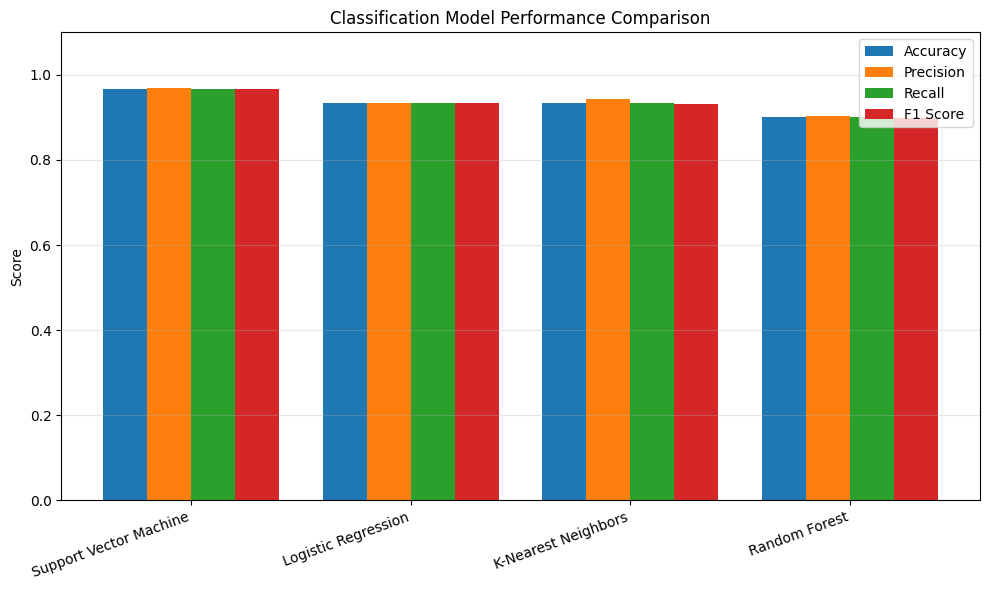

In [21]:
plt.figure(figsize=(10, 6))

x_pos = np.arange(len(results_df))
width = 0.2

plt.bar(
    x_pos - 1.5 * width,
    results_df["Accuracy"],
    width,
    label="Accuracy"
)

plt.bar(
    x_pos - 0.5 * width,
    results_df["Precision"],
    width,
    label="Precision"
)

plt.bar(
    x_pos + 0.5 * width,
    results_df["Recall"],
    width,
    label="Recall"
)

plt.bar(
    x_pos + 1.5 * width,
    results_df["F1 Score"],
    width,
    label="F1 Score"
)

plt.xticks(
    x_pos,
    results_df["Model"],
    rotation=20,
    ha="right"
)

plt.ylabel("Score")
plt.title("Classification Model Performance Comparison")
plt.ylim(0, 1.1)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
best_model_name = results_df.loc[0, "Model"]
best_model = models[best_model_name]

best_accuracy = results_df.loc[0, "Accuracy"]
best_precision = results_df.loc[0, "Precision"]
best_recall = results_df.loc[0, "Recall"]
best_f1 = results_df.loc[0, "F1 Score"]

print("BEST MODEL")
print("=" * 50)
print("Model     :", best_model_name)
print(f"Accuracy  : {best_accuracy:.4f}")
print(f"Precision : {best_precision:.4f}")
print(f"Recall    : {best_recall:.4f}")
print(f"F1 Score  : {best_f1:.4f}")

BEST MODEL
Model     : Support Vector Machine
Accuracy  : 0.9667
Precision : 0.9697
Recall    : 0.9667
F1 Score  : 0.9666


In [23]:
y_pred = best_model.predict(X_test)

print("CLASSIFICATION REPORT")
print("=" * 65)

print(
    classification_report(
        y_test,
        y_pred,
        digits=4
    )
)

CLASSIFICATION REPORT
                 precision    recall  f1-score   support

    Iris-setosa     1.0000    1.0000    1.0000        10
Iris-versicolor     1.0000    0.9000    0.9474        10
 Iris-virginica     0.9091    1.0000    0.9524        10

       accuracy                         0.9667        30
      macro avg     0.9697    0.9667    0.9666        30
   weighted avg     0.9697    0.9667    0.9666        30



CONFUSION MATRIX
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


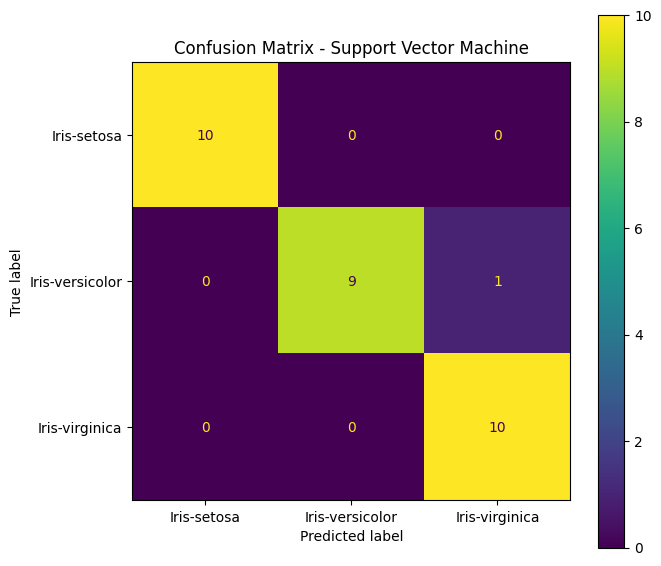

In [24]:
cm = confusion_matrix(y_test, y_pred)

print("CONFUSION MATRIX")
print("=" * 40)
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=best_model.classes_
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax)

plt.title("Confusion Matrix - Support Vector Machine")
plt.tight_layout()
plt.show()

CONFUSION MATRIX
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


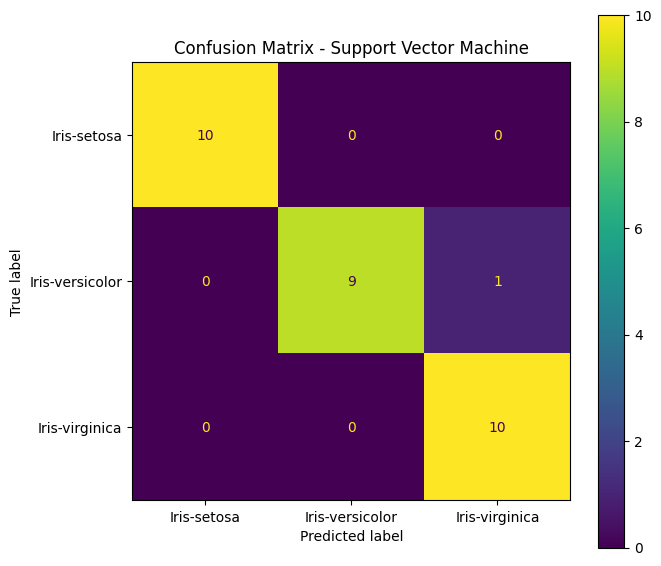

In [25]:
cm = confusion_matrix(y_test, y_pred)

print("CONFUSION MATRIX")
print("=" * 40)
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=best_model.classes_
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax)

plt.title("Confusion Matrix - Support Vector Machine")
plt.tight_layout()
plt.show()

In [26]:
cv_scores = cross_val_score(
    best_model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

print("5-FOLD CROSS-VALIDATION")
print("=" * 50)

for i, score in enumerate(cv_scores, start=1):
    print(f"Fold {i}: Accuracy = {score:.4f}")

print("-" * 50)
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")
print(f"CV Std          : {cv_scores.std():.4f}")

5-FOLD CROSS-VALIDATION
Fold 1: Accuracy = 0.9167
Fold 2: Accuracy = 1.0000
Fold 3: Accuracy = 0.9583
Fold 4: Accuracy = 0.9583
Fold 5: Accuracy = 1.0000
--------------------------------------------------
Mean CV Accuracy: 0.9667
CV Std          : 0.0312


In [27]:
print(f"Mean CV Accuracy : {cv_scores.mean() * 100:.2f}%")
print(f"CV Std           : {cv_scores.std() * 100:.2f}%")

Mean CV Accuracy : 96.67%
CV Std           : 3.12%


In [28]:
comparison_df = pd.DataFrame({
    "Actual Species": y_test.values,
    "Predicted Species": y_pred
})

comparison_df["Correct"] = (
    comparison_df["Actual Species"]
    == comparison_df["Predicted Species"]
)

display(comparison_df)

,Actual Species,Predicted Species,Correct
0,Iris-setosa,Iris-setosa,True
1,Iris-virginica,Iris-virginica,True
2,Iris-versicolor,Iris-versicolor,True
3,Iris-versicolor,Iris-versicolor,True
4,Iris-setosa,Iris-setosa,True
5,Iris-versicolor,Iris-versicolor,True
6,Iris-setosa,Iris-setosa,True
7,Iris-setosa,Iris-setosa,True
8,Iris-virginica,Iris-virginica,True
9,Iris-versicolor,Iris-versicolor,True


In [29]:
misclassified = comparison_df[
    comparison_df["Correct"] == False
]

print("MISCLASSIFIED SAMPLES")
print("=" * 50)

if len(misclassified) == 0:
    print("No misclassified samples found!")
else:
    display(misclassified)
    print(f"\nTotal Misclassified Samples: {len(misclassified)}")

MISCLASSIFIED SAMPLES


,Actual Species,Predicted Species,Correct
25,Iris-versicolor,Iris-virginica,False



Total Misclassified Samples: 1


In [30]:
final_accuracy = accuracy_score(y_test, y_pred)
final_precision = precision_score(
    y_test, y_pred, average="weighted"
)
final_recall = recall_score(
    y_test, y_pred, average="weighted"
)
final_f1 = f1_score(
    y_test, y_pred, average="weighted"
)

print("FINAL MODEL PERFORMANCE")
print("=" * 60)
print("Model              : Support Vector Machine")
print(f"Accuracy           : {final_accuracy:.4f}")
print(f"Accuracy (%)       : {final_accuracy * 100:.2f}%")
print(f"Precision          : {final_precision:.4f}")
print(f"Precision (%)      : {final_precision * 100:.2f}%")
print(f"Recall             : {final_recall:.4f}")
print(f"Recall (%)         : {final_recall * 100:.2f}%")
print(f"F1 Score           : {final_f1:.4f}")
print(f"F1 Score (%)       : {final_f1 * 100:.2f}%")
print("=" * 60)

FINAL MODEL PERFORMANCE
Model              : Support Vector Machine
Accuracy           : 0.9667
Accuracy (%)       : 96.67%
Precision          : 0.9697
Precision (%)      : 96.97%
Recall             : 0.9667
Recall (%)         : 96.67%
F1 Score           : 0.9666
F1 Score (%)       : 96.66%


In [31]:
print("FINAL MODEL VERIFICATION")
print("=" * 60)

print("Best Model       : Support Vector Machine")
print(f"Test Accuracy    : {final_accuracy * 100:.2f}%")
print(f"Precision        : {final_precision * 100:.2f}%")
print(f"Recall           : {final_recall * 100:.2f}%")
print(f"F1 Score         : {final_f1 * 100:.2f}%")
print(f"Mean CV Accuracy : {cv_scores.mean() * 100:.2f}%")
print(f"CV Std           : {cv_scores.std() * 100:.2f}%")
print(f"Misclassified    : {len(misclassified)} / {len(y_test)}")

print("=" * 60)

FINAL MODEL VERIFICATION
Best Model       : Support Vector Machine
Test Accuracy    : 96.67%
Precision        : 96.97%
Recall           : 96.67%
F1 Score         : 96.66%
Mean CV Accuracy : 96.67%
CV Std           : 3.12%
Misclassified    : 1 / 30


In [32]:
prediction_probabilities = best_model.predict_proba(X_test)

probability_df = pd.DataFrame(
    prediction_probabilities,
    columns=best_model.classes_
)

probability_df["Actual Species"] = y_test.values
probability_df["Predicted Species"] = y_pred

display(probability_df.head(10).round(4))

,Iris-setosa,Iris-versicolor,Iris-virginica,Actual Species,Predicted Species
0,0.9610,0.0247,0.0142,Iris-setosa,Iris-setosa
1,0.0116,0.2932,0.6952,Iris-virginica,Iris-virginica
2,0.0403,0.9363,0.0235,Iris-versicolor,Iris-versicolor
3,0.0292,0.9505,0.0203,Iris-versicolor,Iris-versicolor
4,0.9614,0.0217,0.0169,Iris-setosa,Iris-setosa
5,0.0124,0.9024,0.0852,Iris-versicolor,Iris-versicolor
6,0.9536,0.0242,0.0223,Iris-setosa,Iris-setosa
7,0.9617,0.0248,0.0135,Iris-setosa,Iris-setosa
8,0.0096,0.0338,0.9566,Iris-virginica,Iris-virginica
9,0.0154,0.9011,0.0835,Iris-versicolor,Iris-versicolor


In [33]:
sample_results = X_test.copy()

sample_results["Actual Species"] = y_test
sample_results["Predicted Species"] = y_pred
sample_results["Correct"] = (
    sample_results["Actual Species"] ==
    sample_results["Predicted Species"]
)

display(sample_results.head(10))

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Actual Species,Predicted Species,Correct
38,4.4,3.0,1.3,0.2,Iris-setosa,Iris-setosa,True
127,6.1,3.0,4.9,1.8,Iris-virginica,Iris-virginica,True
57,4.9,2.4,3.3,1.0,Iris-versicolor,Iris-versicolor,True
93,5.0,2.3,3.3,1.0,Iris-versicolor,Iris-versicolor,True
42,4.4,3.2,1.3,0.2,Iris-setosa,Iris-setosa,True
56,6.3,3.3,4.7,1.6,Iris-versicolor,Iris-versicolor,True
22,4.6,3.6,1.0,0.2,Iris-setosa,Iris-setosa,True
20,5.4,3.4,1.7,0.2,Iris-setosa,Iris-setosa,True
147,6.5,3.0,5.2,2.0,Iris-virginica,Iris-virginica,True
84,5.4,3.0,4.5,1.5,Iris-versicolor,Iris-versicolor,True


In [35]:
drive_model_path = "/content/drive/MyDrive/iris_species_classification_model.pkl"

joblib.dump(best_model, drive_model_path)

print("Model saved successfully!")
print("Location:", drive_model_path)

Model saved successfully!
Location: /content/drive/MyDrive/iris_species_classification_model.pkl


In [36]:
print("IRIS FLOWER CLASSIFICATION - FINAL SUMMARY")
print("=" * 65)

print("Dataset Size          : 150 samples")
print("Input Features        : 4")
print("Target Classes        : 3")
print("Training Samples      : 120")
print("Testing Samples       : 30")

print("\nFinal Model           : Support Vector Machine")
print(f"Test Accuracy         : {final_accuracy * 100:.2f}%")
print(f"Weighted Precision    : {final_precision * 100:.2f}%")
print(f"Weighted Recall       : {final_recall * 100:.2f}%")
print(f"Weighted F1 Score     : {final_f1 * 100:.2f}%")

print("\nCross-Validation")
print(f"Mean CV Accuracy      : {cv_scores.mean() * 100:.2f}%")
print(f"CV Standard Deviation : {cv_scores.std() * 100:.2f}%")

print("\nError Analysis")
print(f"Misclassified Samples : {len(misclassified)}")
print(f"Correct Predictions   : {len(y_test) - len(misclassified)}")

print("=" * 65)

IRIS FLOWER CLASSIFICATION - FINAL SUMMARY
Dataset Size          : 150 samples
Input Features        : 4
Target Classes        : 3
Training Samples      : 120
Testing Samples       : 30

Final Model           : Support Vector Machine
Test Accuracy         : 96.67%
Weighted Precision    : 96.97%
Weighted Recall       : 96.67%
Weighted F1 Score     : 96.66%

Cross-Validation
Mean CV Accuracy      : 96.67%
CV Standard Deviation : 3.12%

Error Analysis
Misclassified Samples : 1
Correct Predictions   : 29
